# Bi-Encoder Model Training

This notebook documents the retrieval model: its architecture and the two-stage
training procedure. The model maps a query and a passage into the same
256-dimensional space, where relevance is a dot product.

The encoder, the multi-head attention, the contrastive loss and the training
loop are all implemented in [`src/`](../src); this notebook visualises the
results recorded during training under [`runs/`](../runs).

## 1. Architecture

A shared-weight bi-encoder built from plain PyTorch layers (`src/model.py`):

```
input_ids
   │  token embedding (30k WordPiece) + learned positional embedding
   ▼
4 × Transformer block        pre-LayerNorm, manual multi-head self-attention,
   │                         GELU feed-forward (1536), residual connections
   ▼
final LayerNorm
   ▼
mean pooling over non-padding tokens
   ▼
Linear(384 → 256, no bias)
   ▼
L2 normalisation             → unit-norm sentence embedding
```

| Hyper-parameter | Value |
|---|---|
| Vocabulary (own WordPiece) | 30,000 |
| Transformer layers | 4 |
| Model dimension | 384 |
| Attention heads | 6 |
| Feed-forward dimension | 1536 |
| Max sequence length | 320 |
| Projection / embedding dim | 256 |
| Total parameters | ≈ 18.8 M |

The same weights encode queries and passages, which halves the parameter count
and keeps both in a single, consistent embedding space.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
mlm = json.load(open(ROOT / "runs/mlm/history.json"))
con = json.load(open(ROOT / "runs/contrastive/history.json"))
print(f"MLM warm-up: {len(mlm)} epochs   |   contrastive: {len(con)} epochs")

MLM warm-up: 37 epochs   |   contrastive: 13 epochs


## 2. Stage 1 — Self-supervised MLM warm-up

Before contrastive training, the encoder is warmed up with masked-language
modelling on our own corpora (SQuAD passages + training queries + the J&M
book, ~88k texts). 15% of tokens are masked dynamically each epoch and the
model predicts them. This gives a randomly-initialised model basic language
statistics, which substantially improves the contrastive stage that follows.

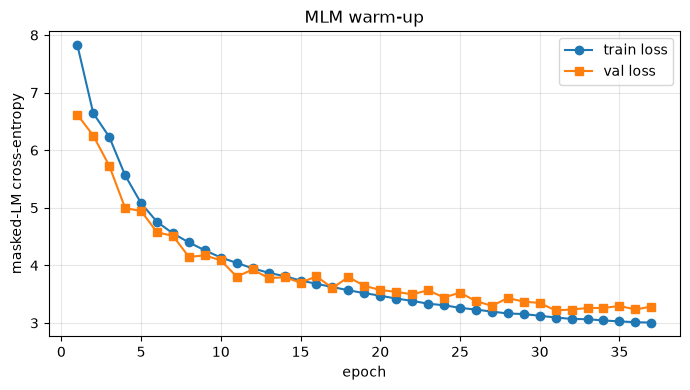

val loss: 6.62 (epoch 1)  ->  3.22 (best)


In [2]:
ep = [h["epoch"] + 1 for h in mlm]
plt.figure(figsize=(7, 4))
plt.plot(ep, [h["train_loss"] for h in mlm], "o-", label="train loss")
plt.plot(ep, [h.get("val_loss") for h in mlm], "s-", label="val loss")
plt.xlabel("epoch"); plt.ylabel("masked-LM cross-entropy"); plt.title("MLM warm-up")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(f"val loss: {mlm[0]['val_loss']:.2f} (epoch 1)  ->  {min(h['val_loss'] for h in mlm if h.get('val_loss')):.2f} (best)")

## 3. Stage 2 — Contrastive training (symmetric InfoNCE)

The warmed-up encoder is then trained with symmetric InfoNCE on (query,
positive passage) pairs. Every other passage in the batch is an in-batch
negative, so at batch size 256 each query is contrasted against 255 negatives.
Because SQuAD has several questions per passage, duplicate positives in a batch
are masked out so a correct passage is never used as its own negative
(`src/losses.py`).

| Setting | Value |
|---|---|
| Loss | symmetric InfoNCE, temperature τ = 0.07 |
| Batch size | 256 (→ 255 in-batch negatives) |
| Optimizer | AdamW, weight decay 0.01 |
| Learning rate | 3e-4, linear warm-up + cosine decay |
| Precision | bf16 autocast |
| Gradient clipping | 1.0 |
| Stopping | early stop on full-corpus validation Recall@10 |

**Model selection.** Validation reports *true* full-corpus Recall@k (each
validation query scored against all 18,891 passages), not the in-batch number,
which saturates almost immediately. The checkpoint with the highest
full-corpus Recall@10 is kept.

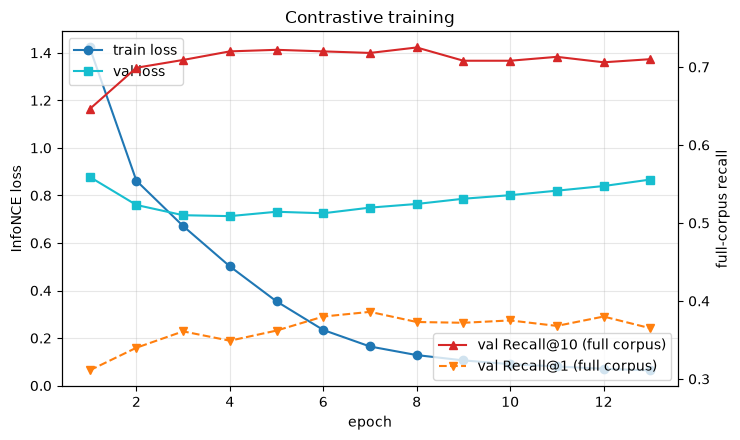

best epoch: 8  |  val Recall@10 = 0.725  |  val Recall@1 = 0.373


In [3]:
ep = [h["epoch"] + 1 for h in con]
fig, ax1 = plt.subplots(figsize=(7.5, 4.5))
ax1.plot(ep, [h["train_loss"] for h in con], "o-", color="tab:blue", label="train loss")
ax1.plot(ep, [h.get("val_loss") for h in con], "s-", color="tab:cyan", label="val loss")
ax1.set_xlabel("epoch"); ax1.set_ylabel("InfoNCE loss"); ax1.grid(alpha=.3)
ax2 = ax1.twinx()
ax2.plot(ep, [h.get("val_r10_full") for h in con], "^-", color="tab:red", label="val Recall@10 (full corpus)")
ax2.plot(ep, [h.get("val_r1_full") for h in con], "v--", color="tab:orange", label="val Recall@1 (full corpus)")
ax2.set_ylabel("full-corpus recall")
ax1.legend(loc="upper left"); ax2.legend(loc="lower right")
plt.title("Contrastive training"); plt.tight_layout(); plt.show()

best = max(con, key=lambda h: h["val_r10_full"])
print(f"best epoch: {best['epoch']+1}  |  val Recall@10 = {best['val_r10_full']:.3f}  |  val Recall@1 = {best['val_r1_full']:.3f}")

## 4. Reading the curves

Training loss keeps falling while validation loss flattens and full-corpus
Recall@10 plateaus — the point where early stopping selects the best
checkpoint. This is the expected behaviour for a model of this size trained on
~70k pairs: beyond the plateau it begins to memorise the training pairs rather
than generalise.

The selected checkpoint is evaluated against the sparse baselines and used for
the semantic-search demo in the next notebook.